In [1]:
import numpy as np
A = np.array([[1, 2, 3], [2, 4, 6], [1, 0, 1]])
print(np.linalg.matrix_rank(A))  # Output: 2

2


In [2]:
import numpy as np
A = np.array([[2, 4, -2], [4, 9, -3], [-2, -3, 7]])
print(np.linalg.matrix_rank(A))  # Output: 3

3


In [3]:
A = np.array([[1, 2],
              [3, 4]])

# Compute eigenvalues and eigenvectors
eigenvalues, P = np.linalg.eig(A)

print("Eigenvalues:", eigenvalues)
print("Eigenvector matrix P:\n", P)

Eigenvalues: [-0.37228132  5.37228132]
Eigenvector matrix P:
 [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


In [ ]:
print((5-sqrt(15))/4)

In [3]:
import time
import torch
n = 10000
a = torch.ones(n)
b = torch.ones(n)

c = torch.zeros(n)
t = time.time()
#For loop method
for i in range(n):
    c[i] = a[i] + b[i]
print(f'{time.time() - t:.5f} sec') #0.05414 sec
#Vector sum
t = time.time()
d = a + b
print(f'{time.time() - t:.5f} sec') #0.00022 sec



0.05414 sec
0.00022 sec


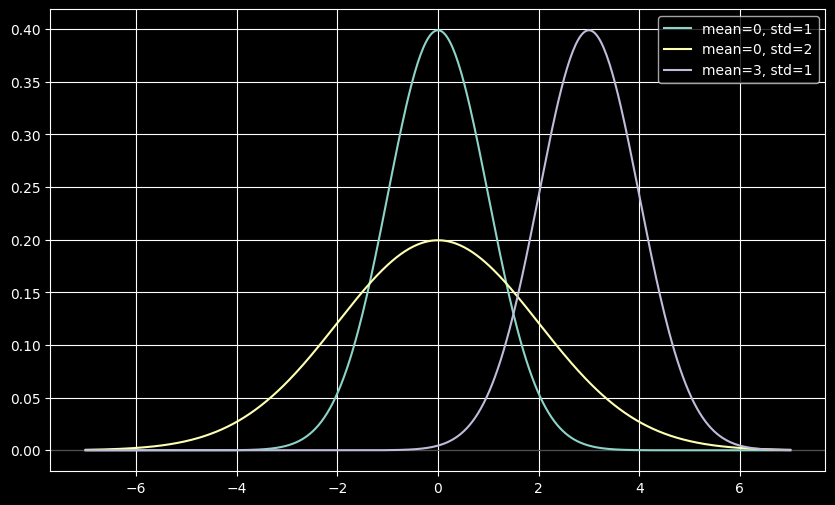

In [2]:

from statistics.distributions import normal
from plotting.plotter import Plotter

params = [(0, 1), (0, 2), (3, 1)]

plotter = Plotter(-7, 7, (10, 6), 500)

x = plotter.x


plotter.plot(
    [normal(x, mu, sigma) for mu, sigma in params],
    [f"mean={mu}, std={sigma}" for mu, sigma in params]
)

plotter.show()

# Implementation of Linear regression step by step

We'll build a linear regression model trained via **Stochastic Gradient Descent (SGD)**. The goal: learn weights $w$ and bias $b$ such that $ŷ = w·x + b$ minimizes the mean squared error on a synthetic dataset.

## Matrix formulation
With $n$ samples and $m=2$ features, we pack everything into:

$X \in \mathbb{R}^{(n,m)}$ → design matrix

$w \in \mathbb{R}^{(m,1)}$ → weight vector

$b$ → scalar bias

$y \in \mathbb{R}^{(n,1)} $ → targets

Forward pass becomes: $ŷ = X @ w + b$, giving shape $(n, 1)$.

## Sample space generation
Start by creating a synthetic dataset with a known linear relationship plus some noise:

In [11]:
import numpy as np

# The seed is given an integer value to ensure that the results of pseudo-random generation are reproducible. By re-using a seed value, the same sequence should be reproducible from run to run as long as multiple threads are not running. Reproducibility is a very important concept that ensures that anyone who re-runs the code gets the exact same outputs.
# 42 is the Answer to the great question of “Life, the universe, and everything”!
np.random.seed(42)
n, m = 200, 2

#generates the design matrix
X = np.random.uniform(-5, 5, (n, m))        # shape (n, m)

#values for true weights and bias
true_w = np.array([[3.0], [-2.0]])           # shape (m, 1)
true_b = 1.5

noise = np.random.normal(0, 1.0, (n, 1)) #normal distribution mean=0 stand_dev=1

y = X @ true_w + true_b + noise             # shape (n, 1)      # targets


This means the true target is

$$y=3x_1-2x_2+1.5 + noise$$

That is what we will try to find

## Initialise parameters


In [26]:
w = np.random.randn(m, 1)    # shape (2, 1)
b = 0.0
eta = 0.01 #learning rate
epochs = 71 #itarations
s = 2               # pure Minibatch SGD — s=2 sample at a time

## SGD loop

With matrix calculations.
The loss function over a minibatch size $s$ is



In [32]:
for epoch in range(epochs):
    indices = np.random.permutation(n)        # ← shuffle once per epoch

    for start in range(0, n, s):
        idx = indices[start:start + s] #we take a minibatch size of sample indices
        xi = X[idx]        # shape (s, m)
        yi = y[idx]        # shape (s, 1)

        y_pred = xi @ w + b
        error = y_pred - yi

        dw = 2 * xi.T @ error    # shape (2, 1)
        db = 2 * np.mean(error) #scalar

        w -= 2*eta/s * dw
        b -= 2*eta/s * db
    #track the loss at every epoch
    y_all_pred = X @ w + b           # shape (n, 1)
    mse = np.mean((y_all_pred - y) ** 2) #mean squared error -> mean((ŷ - y)²)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | MSE: {mse:.4f} | w: {w.ravel()} | b: {b:.4f}")
print(f"\nLearned:  w = {w.ravel()}, b = {b:.4f}")
print(f"True:     w = {true_w.ravel()}, b = {true_b}")

Epoch   0 | MSE: 1.4098 | w: [ 3.17733381 -1.89433841] | b: 1.4795
Epoch  10 | MSE: 1.0244 | w: [ 3.0443967  -1.95495537] | b: 1.4454
Epoch  20 | MSE: 1.0250 | w: [ 2.92328966 -2.0389086 ] | b: 1.4178
Epoch  30 | MSE: 1.1455 | w: [ 3.12536326 -1.97868658] | b: 1.4643
Epoch  40 | MSE: 0.9824 | w: [ 2.96708134 -1.97749799] | b: 1.4663
Epoch  50 | MSE: 0.9899 | w: [ 3.03715343 -2.00535642] | b: 1.4708
Epoch  60 | MSE: 1.9324 | w: [ 2.66398143 -2.00124091] | b: 1.4441
Epoch  70 | MSE: 1.2686 | w: [ 3.17137694 -2.00112623] | b: 1.4509

Learned:  w = [ 3.17137694 -2.00112623], b = 1.4509
True:     w = [ 3. -2.], b = 1.5


Note: The shuffle is important — without it you'd iterate through the data in the same fixed order every epoch, which can introduce bias in the gradient updates and slow convergence. Shuffling ensures each epoch sees the data in a different order, which is part of what makes SGD's noisy updates beneficial for escaping local structure.

In this regression, once training converges, **the MSE should approach the noise variance** — in this case 1.0²= 1.0 — since that's the irreducible error baked into the data generation.